In [5]:
import pandas as pd
import matplotlib.pyplot as plt
students=pd.read_excel("Students.xlsx")
courses=pd.read_excel("Courses.xlsx")
enrollments=pd.read_excel('Enrollements.xlsx')
print("\nStudents")
print(students)
print("\nCourses")
print(courses)
print("\nEnrollments")
print(enrollments)


Students
   StudentID StudentName  Gender        City
0       S001       Aisha  Female       Kochi
1       S002       Rahul    Male  Trivandrum
2       S003        Neha  Female   Kozhikode
3       S004       Arjun    Male       Kochi
4       S005       Priya  Female    Thrissur
5       S006       Akash    Male  Trivandrum
6       S007       Sneha  Female      Kollam
7       S008       Vivek    Male   Kozhikode
8       S009       Meera  Female       Kochi
9       S010       Kiran    Male    Thrissur
10      S011      Anjali  Female      Kollam
11      S012       Rohit    Male       Kochi
12      S013      Nithya  Female   Kozhikode
13      S014        Ajay    Male  Trivandrum
14      S015        Diya  Female       Kochi

Courses
  CourseID        CourseName      Category    Fee
0     C101     Python Basics   Programming   5000
1     C102     Data Analysis  Data Science   8000
2     C103  Machine Learning  Data Science  12000
3     C104   Web Development   Programming   9000
4     C105 

In [6]:
print("\nFirst Five Students")
print(students.head())
print("\nFirst Five Courses")
print(courses.head())
print("\nFirst Five Enrollments")
print(enrollments.head())


First Five Students
  StudentID StudentName  Gender        City
0      S001       Aisha  Female       Kochi
1      S002       Rahul    Male  Trivandrum
2      S003        Neha  Female   Kozhikode
3      S004       Arjun    Male       Kochi
4      S005       Priya  Female    Thrissur

First Five Courses
  CourseID        CourseName      Category    Fee
0     C101     Python Basics   Programming   5000
1     C102     Data Analysis  Data Science   8000
2     C103  Machine Learning  Data Science  12000
3     C104   Web Development   Programming   9000
4     C105  SQL Fundamentals      Database   6000

First Five Enrollments
  EnrollmentID StudentID CourseID EnrollmentDate  Marks
0         E001      S001     C101     2025-01-05     85
1         E002      S002     C102     2025-01-08     78
2         E003      S003     C101     2025-01-15     92
3         E004      S004     C104     2025-01-20     75
4         E005      S005     C105     2025-02-02     88


In [7]:
merged = (
    students
    .merge(enrollments,on='StudentID',how='left')
    .merge(courses,on='CourseID',how='left')
)

print(merged.head())

  StudentID StudentName  Gender        City EnrollmentID CourseID  \
0      S001       Aisha  Female       Kochi         E001     C101   
1      S001       Aisha  Female       Kochi         E016     C102   
2      S002       Rahul    Male  Trivandrum         E002     C102   
3      S002       Rahul    Male  Trivandrum         E017     C103   
4      S003        Neha  Female   Kozhikode         E003     C101   

  EnrollmentDate  Marks        CourseName      Category    Fee  
0     2025-01-05     85     Python Basics   Programming   5000  
1     2025-04-20     84     Data Analysis  Data Science   8000  
2     2025-01-08     78     Data Analysis  Data Science   8000  
3     2025-05-02     76  Machine Learning  Data Science  12000  
4     2025-01-15     92     Python Basics   Programming   5000  


In [9]:
merged['Revenue'] = merged['Fee']
print(merged.head())

  StudentID StudentName  Gender        City EnrollmentID CourseID  \
0      S001       Aisha  Female       Kochi         E001     C101   
1      S001       Aisha  Female       Kochi         E016     C102   
2      S002       Rahul    Male  Trivandrum         E002     C102   
3      S002       Rahul    Male  Trivandrum         E017     C103   
4      S003        Neha  Female   Kozhikode         E003     C101   

  EnrollmentDate  Marks        CourseName      Category    Fee  Revenue  
0     2025-01-05     85     Python Basics   Programming   5000     5000  
1     2025-04-20     84     Data Analysis  Data Science   8000     8000  
2     2025-01-08     78     Data Analysis  Data Science   8000     8000  
3     2025-05-02     76  Machine Learning  Data Science  12000    12000  
4     2025-01-15     92     Python Basics   Programming   5000     5000  


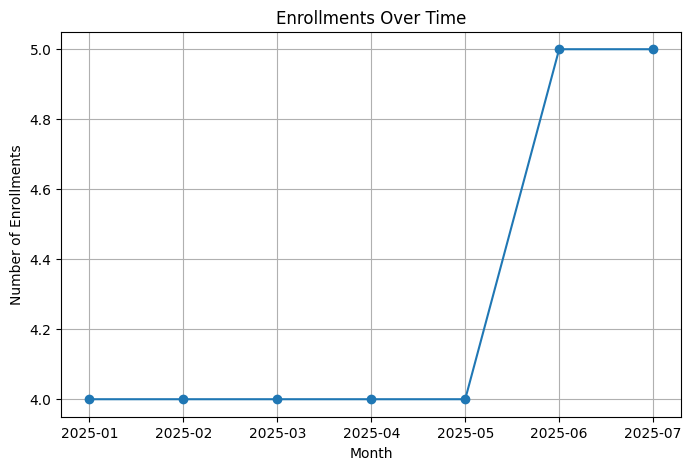

In [21]:
enrollments['EnrollmentDate']=pd.to_datetime(enrollments['EnrollmentDate'])
monthly_enrollments=(enrollments.groupby(enrollments['EnrollmentDate'].dt.to_period('M')).size())
plt.figure(figsize=(8,5))
plt.plot(monthly_enrollments.index.astype(str),monthly_enrollments.values,marker='o')
plt.title("Enrollments Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Enrollments")
plt.grid(True)
plt.show()

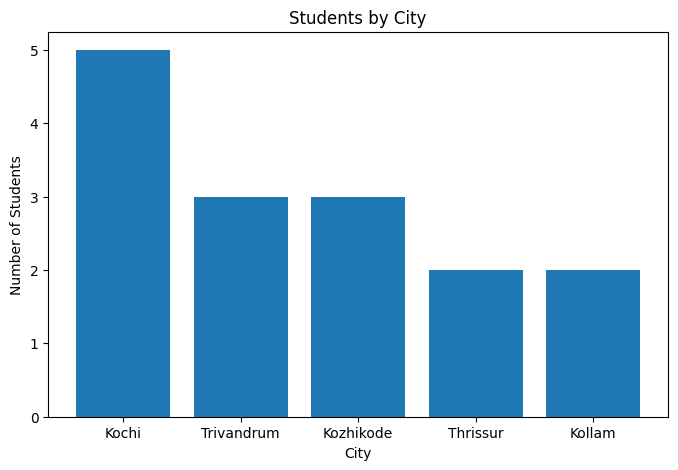

In [22]:
city_counts=students['City'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(city_counts.index,city_counts.values)
plt.title("Students by City")
plt.xlabel("City")
plt.ylabel("Number of Students")
plt.show()

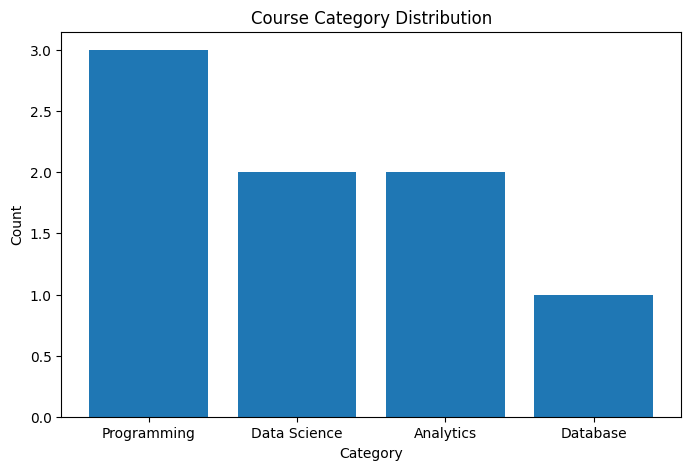

In [23]:
category_counts=courses['Category'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Course Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

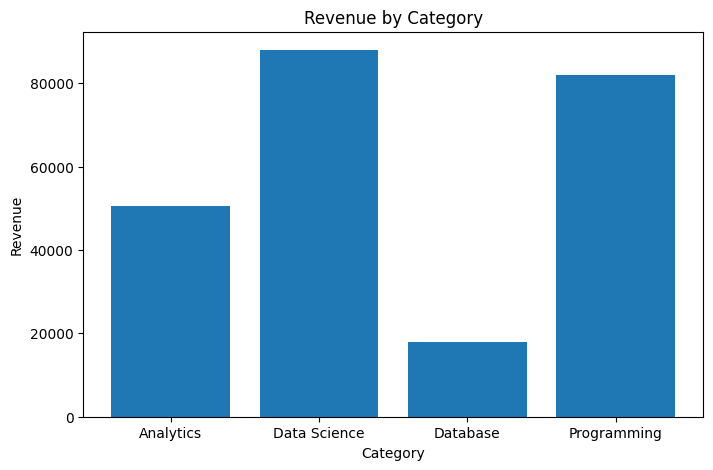

In [24]:
revenue_by_category=(merged.groupby('Category')['Revenue'].sum())
plt.figure(figsize=(8,5))
plt.bar(revenue_by_category.index,revenue_by_category.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

CourseName
Data Analysis       5
Python Basics       5
Power BI            4
Machine Learning    4
Advanced Python     3
SQL Fundamentals    3
Tableau             3
Web Development     3
dtype: int64


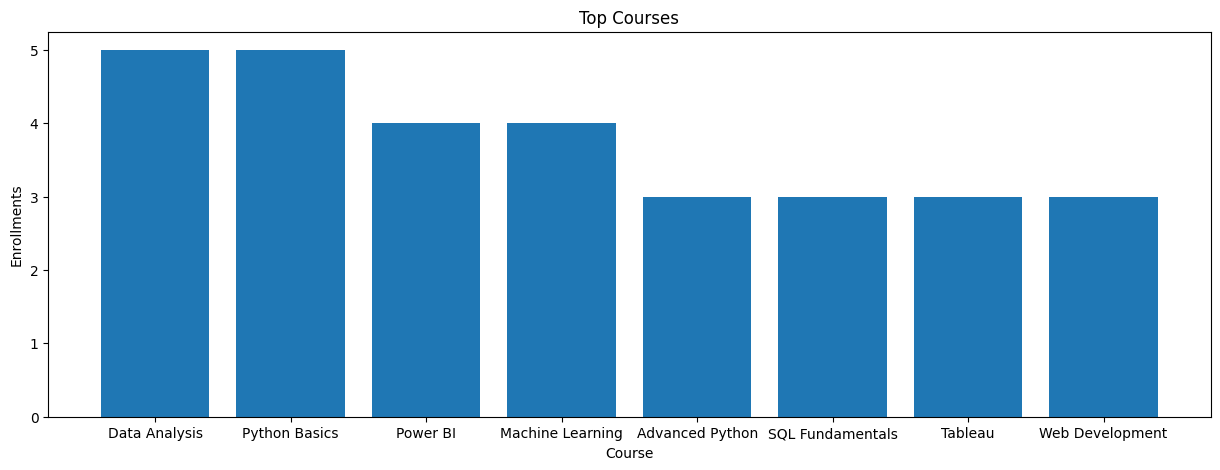

In [25]:
top_courses=(merged.groupby('CourseName').size().sort_values(ascending=False))
print(top_courses)
plt.figure(figsize=(15,5))
plt.bar(top_courses.index,top_courses.values)
plt.title("Top Courses")
plt.xlabel("Course")
plt.ylabel("Enrollments")
plt.show()

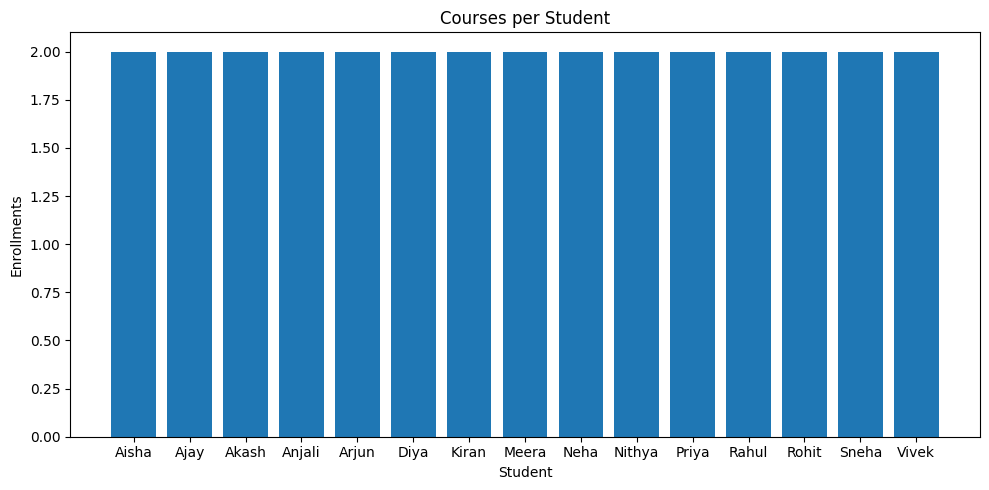

In [26]:
student_activity=(merged.groupby('StudentName').size())
plt.figure(figsize=(10,5))
plt.bar(student_activity.index,student_activity.values)
plt.title("Courses per Student")
plt.xlabel("Student")
plt.ylabel("Enrollments")
plt.tight_layout()
plt.show()

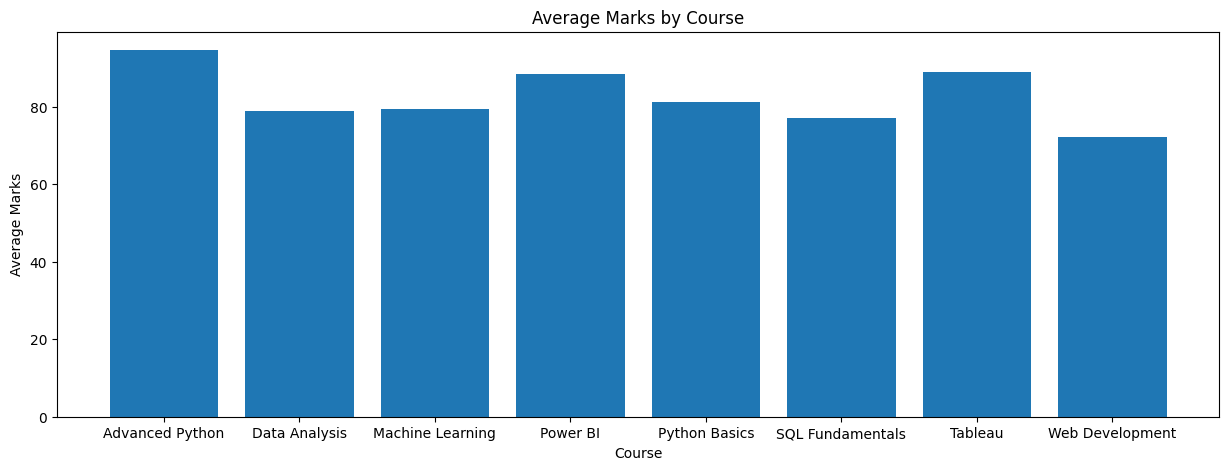

In [28]:
course_marks=(merged.groupby('CourseName')['Marks'].mean())
plt.figure(figsize=(15,5))
plt.bar(course_marks.index,course_marks.values)
plt.title("Average Marks by Course")
plt.xlabel("Course")
plt.ylabel("Average Marks")
plt.show()

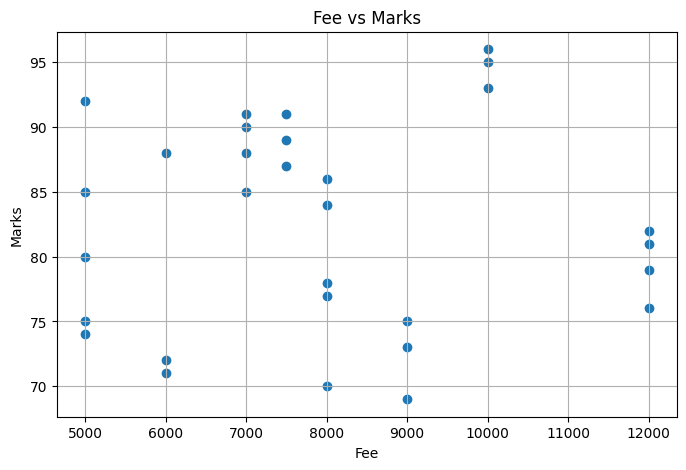

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(merged['Fee'],merged['Marks'])
plt.title("Fee vs Marks")
plt.xlabel("Fee")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

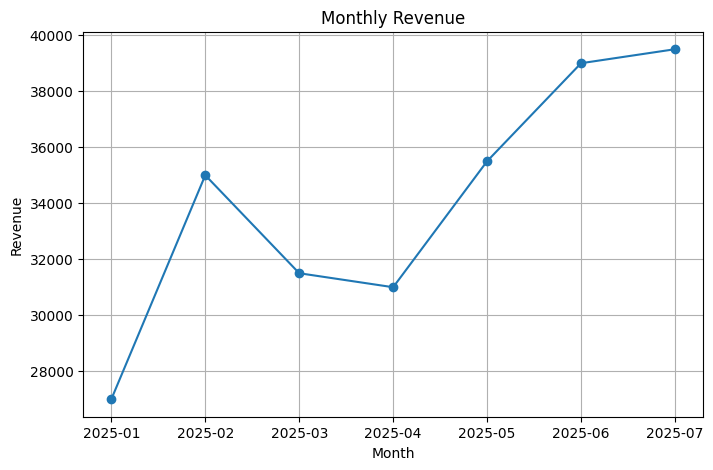

In [35]:
merged['Month']=(merged['EnrollmentDate'].dt.to_period('M'))
monthly_revenue = (merged.groupby('Month')['Revenue'].sum())
plt.figure(figsize=(8,5))
plt.plot( monthly_revenue.index.astype(str),monthly_revenue.values, marker='o')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

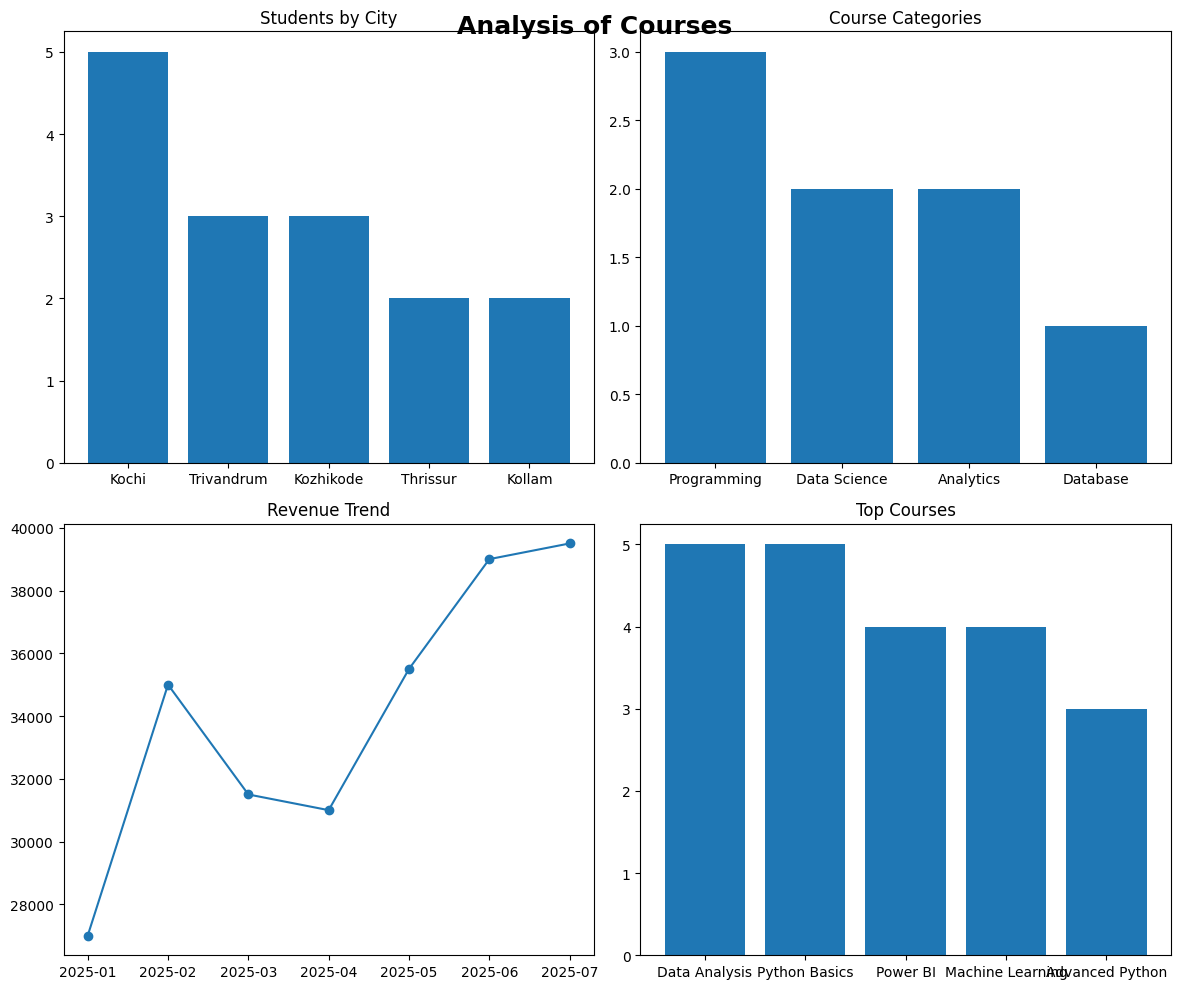

In [37]:
fig, ax = plt.subplots(2,2,figsize=(12,10))
# Students by City
ax[0,0].bar(city_counts.index,city_counts.values)
ax[0,0].set_title("Students by City")
# Categories
ax[0,1].bar(category_counts.index,category_counts.values)
ax[0,1].set_title("Course Categories")
# Revenue
ax[1,0].plot(monthly_revenue.index.astype(str),monthly_revenue.values,marker='o')
ax[1,0].set_title("Revenue Trend")
# Top Courses
ax[1,1].bar(top_courses.head().index,top_courses.head().values)
ax[1,1].set_title("Top Courses")
plt.tight_layout()
plt.suptitle('Analysis of Courses',fontsize=18,fontweight='bold')
plt.show()